# Initial setups

mount google drive and authenticate to access files

In [1]:
#connect to runtime GPU
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


check the currect directory content

In [2]:
! ls
#%cd ML-CWs

gdrive	sample_data


change directory to specific dir

In [3]:
%cd gdrive/MyDrive/'Collaborate '

/content/gdrive/MyDrive/Collaborate 


install any package if missing

In [4]:
#! pip install <desired-python-library>

check the access of any file

# Tutorial: 1-2

In [5]:
# report writing

# Tutorial: 3

Load a CSV file into a list

In [6]:
import csv

In [7]:
filename = 'Tutorial_3_data.csv'
header = []
data = []

In [8]:
csvfile = open(filename)
content_of_file = csv.reader(csvfile)

In [9]:
header = next(content_of_file)
for row in content_of_file:
  data.append(row)

In [10]:
csvfile.close()

Manipulation of data

In [11]:
print(len(data))
print(type(data))

2
<class 'list'>


In [12]:
x = data[1]
y = data[0]
print(type(x))
print(type(y))

<class 'list'>
<class 'list'>


In [13]:
valueofx = float(x[4])
valueofy = float(y[4])
print(valueofx)
print(valueofy)

dataofx = float(data[0][4])
dataofy = float(data[1][4])
print(type(dataofx))
print(type(dataofy))

print(valueofx * valueofy)
print(dataofx * dataofy)

0.00684158
-9.2
<class 'float'>
<class 'float'>
-0.062942536
-0.062942536


Plotting

In [14]:
import matplotlib.pyplot as plt

In [15]:
x = [float(i) for i in data[0]]
y = [float(i) for i in data[1]]

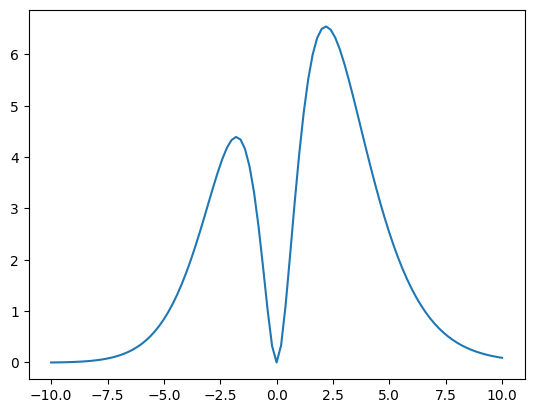

In [16]:
plt.plot(x,y)

# Tutorial: 4

AdaBoost and KNN implementation

In [17]:
import numpy as np
import csv

In [18]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

loading and manipulation of data

In [19]:
filename = 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
data = []
header = []
label = []
csvfile = open(filename)
csvreader = csv.reader(csvfile)

In [20]:
header = next(csvreader)
for row in csvreader:
  data.append(row[0:-2])
  if(row[-1] == 'BENIGN'):
    label.append(0)
  else:
    label.append(1)

data_mat = np.array(data)
label_mat = np.array(label)
csvfile.close()

ADABoost implementation

In [21]:
clf = AdaBoostClassifier(n_estimators = 10, random_state = 0)
clf.fit(data_mat, label_mat)

AdaBoostClassifier(n_estimators=10, random_state=0)

In [22]:
label_hat = clf.predict(data_mat)

p1 = precision_score(label_mat, label_hat)
R1 = recall_score(label_mat, label_hat)
F1 = f1_score(label_mat, label_hat)

print(p1, R1, F1)

0.9992731592562778 0.9986799659446836 0.9989764745407809


In [23]:
print(data_mat.dtype)
print(data_mat[:3])

<U11
[['54865' '3' '2' '0' '12' '0' '6' '6' '6' '0' '0' '0' '0' '0' '4000000'
  '666666.6667' '3' '0' '3' '3' '3' '3' '0' '3' '3' '0' '0' '0' '0' '0'
  '0' '0' '0' '0' '40' '0' '666666.6667' '0' '6' '6' '6' '0' '0' '0' '0'
  '0' '0' '1' '0' '0' '0' '0' '9' '6' '0' '40' '0' '0' '0' '0' '0' '0'
  '2' '12' '0' '0' '33' '-1' '1' '20' '0' '0' '0' '0' '0' '0' '0']
 ['55054' '109' '1' '1' '6' '6' '6' '6' '6' '0' '6' '6' '6' '0'
  '110091.7431' '18348.62385' '109' '0' '109' '109' '0' '0' '0' '0' '0'
  '0' '0' '0' '0' '0' '0' '0' '0' '0' '20' '20' '9174.311927'
  '9174.311927' '6' '6' '6' '0' '0' '0' '0' '0' '0' '1' '1' '0' '0' '1'
  '9' '6' '6' '20' '0' '0' '0' '0' '0' '0' '1' '6' '1' '6' '29' '256' '0'
  '20' '0' '0' '0' '0' '0' '0' '0']
 ['55055' '52' '1' '1' '6' '6' '6' '6' '6' '0' '6' '6' '6' '0'
  '230769.2308' '38461.53846' '52' '0' '52' '52' '0' '0' '0' '0' '0' '0'
  '0' '0' '0' '0' '0' '0' '0' '0' '20' '20' '19230.76923' '19230.76923'
  '6' '6' '6' '0' '0' '0' '0' '0' '0' '1' '1' '0' '

In [24]:
data_mat = data_mat.astype(float)

KNN implementation

In [25]:
knnClf = KNeighborsClassifier(n_neighbors=5)
knnClf.fit(data_mat, label_mat)
knn_Label_hat = knnClf.predict(data_mat)

In [26]:
knn_p1 = precision_score(label_mat, knn_Label_hat)
knn_R1 = recall_score(label_mat, label_hat)
knn_F1 = f1_score(label_mat, label_hat)
print(knn_p1,knn_R1, knn_F1)

0.9982752969454807 0.9986799659446836 0.9989764745407809


In [27]:
from sklearn.metrics import accuracy_score

In [28]:
Pr=np.array([])
Rc=np.array([])
F1=np.array([])
Acc=np.array([])

for n in range(20):
    clf = KNeighborsClassifier(n_neighbors=n+1)
    clf.fit(data_mat, label_mat)
    label_hat=clf.predict(data_mat)

    Pr = np.append(Pr,precision_score(label_mat,label_hat))
    Rc = np.append(Rc,recall_score(label_mat,label_hat))
    F1 = np.append(F1,f1_score(label_mat,label_hat))
    Acc = np.append(Acc,accuracy_score(label_mat,label_hat))

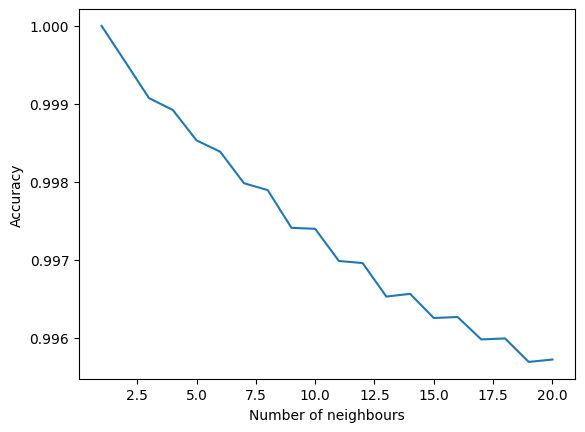

In [29]:
plt.plot(np.arange(20)+1,Acc)
plt.xlabel('Number of neighbours')
plt.ylabel('Accuracy')

plt.show()

optimization with Adaboost

In [30]:
#estimatorList = [1,10,20,30,50,70,100]
estimatorList = [1,10,20]
for count in estimatorList:
    clf = AdaBoostClassifier(n_estimators = count, random_state = 0)
    clf.fit(data_mat, label_mat)

    label_hat = clf.predict(data_mat)

    p1 = precision_score(label_mat, label_hat)
    R1 = recall_score(label_mat, label_hat)
    F1 = f1_score(label_mat, label_hat)

    print(count, p1, R1, F1)

1 0.8153495392336056 1.0 0.8982837978165081
10 0.9992731592562778 0.9986799659446836 0.9989764745407809
20 0.9991796490460491 0.9989221023690316 0.9990508591092137


optimization with KNN

In [31]:
knn_p1 = np.array([])

#neighborList = [1,2,3,4,5,6,7,8,9,10]
neighborList = [1,2,3]
for i in neighborList:
    knnClf = KNeighborsClassifier(n_neighbors=i)
    knnClf.fit(data_mat, label_mat)
    knn_Label_hat = knnClf.predict(data_mat)
    knn_p1 = np.append(knn_p1, precision_score(label_mat, knn_Label_hat))


[1.         1.         0.99896162]


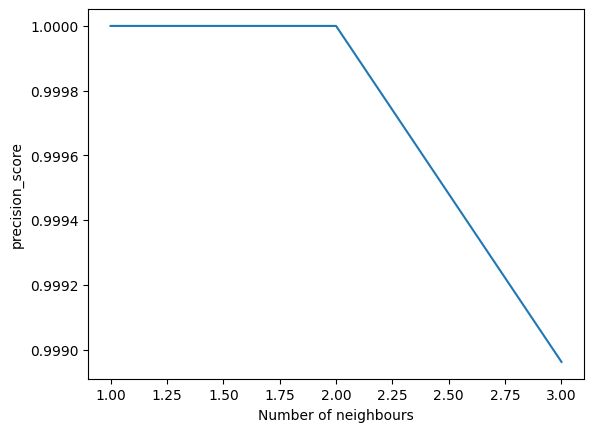

In [32]:
print(knn_p1)
plt.plot(neighborList, knn_p1)
plt.xlabel('Number of neighbours')
plt.ylabel('precision_score')
plt.show()

# Tutorial: 5

K-Fold implementation

In [33]:
import numpy as np
import csv

from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, KFold

import matplotlib.pyplot as plt


In [34]:
filename = 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
data = []
header = []
label = []
csvfile = open(filename)
csvreader = csv.reader(csvfile)

header = next(csvreader)
for row in csvreader:
  data.append(row[0:-2])
  if(row[-1] == 'BENIGN'):
    label.append(0)
  else:
    label.append(1)

data_mat = np.array(data)
label_mat = np.array(label)
csvfile.close()
print(data_mat.shape)

(225733, 77)


just to check how kfold works

In [35]:
kf = KFold(n_splits = 10)
kf_split = kf.split(data_mat)
fold_index = next(kf_split)
print(kf_split)

<generator object _BaseKFold.split at 0x7fee07a36570>


In [36]:
kf = KFold(n_splits = 10, shuffle = True)

Pr=np.zeros(10)
Rc=np.zeros(10)
F1=np.zeros(10)

for count, (train, test) in enumerate(kf.split(data_mat)):
  train_data = data_mat[train, :]
  train_label = label_mat[train]
  test_data = data_mat[test, :]
  test_label = label_mat[test]

  clf = AdaBoostClassifier(n_estimators = 1, random_state = 0)
  clf.fit(train_data, train_label)

  test_hat = clf.predict(test_data)

  Pr[count] = precision_score(test_label, test_hat)
  Rc[count] = recall_score(test_label, test_hat)
  F1[count] = f1_score(test_label, test_hat)

print(np.mean(Pr), np.std(Pr))

0.8153513126250106 0.001779293864573778


 Mean Precision: 0.82 
 Standard deviation of Precision: 0.00


/tmp/ipykernel_957/3832911863.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot1 = plt.boxplot([Pr, Rc, F1],


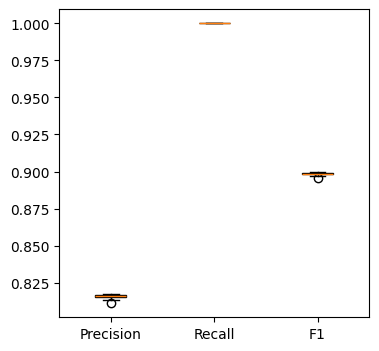

In [37]:
#################################################################################################################
## Printing mean and standard deviation of the precision score
#################################################################################################################
Pr_mean=np.mean(Pr)
Pr_std=np.std(Pr)

print(' Mean Precision: {:.2f} \n Standard deviation of Precision: {:.2f}'.format(Pr_mean, Pr_std))


fig  = plt.figure(figsize=(4, 4))
bplot1 = plt.boxplot([Pr, Rc, F1],
                         vert=True,  # vertical box alignment
                         patch_artist=True,  # fill with color
                         labels=['Precision','Recall','F1'])  # will be used to label x-ticks

#################################################################################################################
## Plotting boxplots for the scores
#################################################################################################################

colors = ['lightblue', 'pink', 'lightgreen']
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

In [38]:
kf = StratifiedKFold(n_splits = 10, shuffle = True)

Pr=np.zeros(10)
Rc=np.zeros(10)
F1=np.zeros(10)
for count, (train, test) in enumerate(kf.split(data_mat, label_mat)):
  train_data = data_mat[train, :]
  train_label = label_mat[train]
  test_data = data_mat[test, :]
  test_label = label_mat[test]
  print("For next fold:", count)

  clf = AdaBoostClassifier(n_estimators = count+1, random_state = 0)
  clf.fit(train_data, train_label)

  test_hat = clf.predict(test_data)

  Pr[count] = precision_score(test_label, test_hat)
  Rc[count] = recall_score(test_label, test_hat)
  F1[count] = f1_score(test_label, test_hat)

print(count, np.mean(Pr), np.std(Pr))

For next fold: 0
For next fold: 1
For next fold: 2
For next fold: 3
For next fold: 4
For next fold: 5
For next fold: 6
For next fold: 7
For next fold: 8
For next fold: 9
9 0.9546494719154575 0.0784053373166779


In [40]:
data_mat = data_mat.astype(float)  # fix the dtype issue

kf = StratifiedKFold(n_splits = 10, shuffle = True)
Acc_mean=np.zeros(2)
for i in range(2):
    Pr_knn=np.zeros(10)
    Rc_knn=np.zeros(10)
    F1_knn=np.zeros(10)
    Acc_knn=np.zeros(10)

    for count, (train, test) in enumerate(kf.split(data_mat, label_mat)):
      train_data = data_mat[train, :]
      train_label = label_mat[train]
      test_data = data_mat[test, :]
      test_label = label_mat[test]

      print("For next fold:", count)
      knn_p1 = []

      knnClf = KNeighborsClassifier(n_neighbors=i+1)
      knnClf.fit(train_data, train_label)
      knn_Label_hat = knnClf.predict(test_data)

      knn_p1.append(precision_score(test_label, knn_Label_hat))
      Acc_knn[count] = accuracy_score(test_label, knn_Label_hat)
    Acc_mean = np.append(Acc_mean,np.mean(Acc_knn))


For next fold: 0
For next fold: 1
For next fold: 2
For next fold: 3
For next fold: 4
For next fold: 5
For next fold: 6
For next fold: 7
For next fold: 8
For next fold: 9
For next fold: 0
For next fold: 1
For next fold: 2
For next fold: 3
For next fold: 4
For next fold: 5
For next fold: 6
For next fold: 7
For next fold: 8
For next fold: 9


[0.         0.         0.99871087 0.99849823]


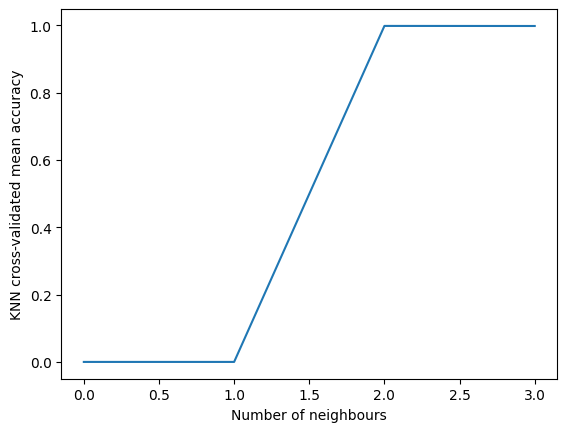

In [41]:
print(Acc_mean)
plt.plot(np.arange(4), Acc_mean)
plt.xlabel('Number of neighbours')
plt.ylabel('KNN cross-validated mean accuracy')
plt.show()

# Tutorial: 6

In [42]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [43]:
filename = 'ADNI_Tadpole_data_tutorial.xlsx'
data_df = pd.read_excel(filename)
data_df.head()

y_target = data_df['Amyloid status']
x_data = data_df.drop(['PTID','SUVR','Amyloid status'], axis = 1)

In [ ]:
data_df.head()


logistic Regression

In [44]:
clf = LogisticRegression()
clf.fit(x_data, y_target)

y_hat = clf.predict(x_data)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


confusion matrix and AUC

AUC: 0.6773
Accuracy: 0.7009


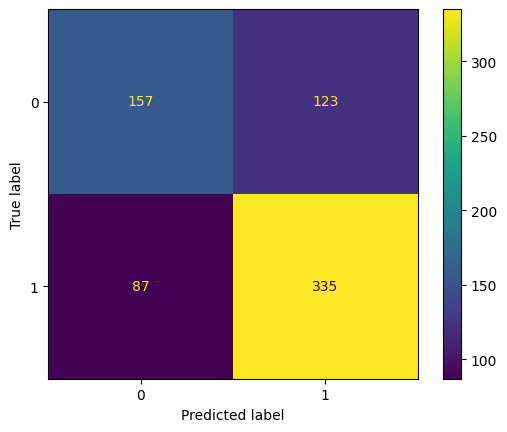

In [45]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score

print('AUC: {:.4f}'.format(roc_auc_score(y_target, y_hat)))
print('Accuracy: {:.4f}'.format(accuracy_score(y_target, y_hat>0.6)))

cm = confusion_matrix(y_target, y_hat>0.6)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

In [46]:
y_target = data_df['Amyloid status']
x_data = data_df[['AGE','GENDER','EDUCATION', 'ApoE4']]

In [48]:
clf = LogisticRegression(penalty=None, class_weight=None, max_iter=10000, solver='saga' )
clf.fit(x_data, y_target)

y_hat = clf.predict(x_data)
y_prob = clf.predict_proba(x_data)

In [49]:
print(clf.coef_, clf.intercept_)

[[ 0.03238826 -0.19565783 -0.13585496  1.69536532]] [-0.43764757]


train test split

In [50]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_target, train_size=0.75)

clf = LogisticRegression(penalty=None, class_weight=None, max_iter=10000, solver='saga' )
clf.fit(x_train, y_train)

y_hat = clf.predict(x_test)
y_prob = clf.predict_proba(x_test)

AUC: 0.6688
Accuracy: 0.6761


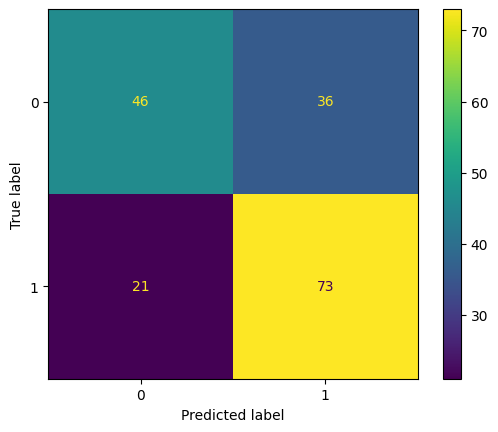

In [51]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score

print('AUC: {:.4f}'.format(roc_auc_score(y_test, y_hat)))
print('Accuracy: {:.4f}'.format(accuracy_score(y_test, y_hat>0.6)))

cm = confusion_matrix(y_test, y_hat>0.6)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

10 fold cross validation with logistic regression

In [52]:
kf = KFold(n_splits = 10, shuffle = True)

auc=np.zeros(10)
acc=np.zeros(10)

data_mat = np.array(x_data)
label_mat = np.array(y_target)

for count, (train, test) in enumerate(kf.split(data_mat)):
  train_data = data_mat[train, :]
  train_label = label_mat[train]
  test_data = data_mat[test, :]
  test_label = label_mat[test]

  clf = LogisticRegression(penalty=None, class_weight=None, max_iter=10000, solver='saga' )
  clf.fit(train_data, train_label)

  y_hat = clf.predict(test_data)
  y_prob = clf.predict_proba(test_data)

  auc[count] = roc_auc_score(test_label, y_hat)
  acc[count] = accuracy_score(test_label, y_hat>0.6)
  print(count, auc[count], acc[count])


0 0.7112794612794612 0.704225352112676
1 0.7696314102564102 0.7746478873239436
2 0.713768115942029 0.7285714285714285
3 0.7588285960378984 0.7714285714285715
4 0.719703977798335 0.7428571428571429
5 0.7321428571428572 0.7428571428571429
6 0.732968881412952 0.7285714285714285
7 0.6392301392301392 0.6428571428571429
8 0.7311111111111112 0.7571428571428571
9 0.6603618421052632 0.6714285714285714


In [53]:
print(np.mean(auc), np.mean(acc))

0.7169026392316455 0.7264587525150905
